In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../../Data/creditcard.csv')

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0



df
train, val, test -> save 
train, val,  -> 80, 20 

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import precision_score, accuracy_score, classification_report, make_scorer

In [6]:
len(df)*20 // 100

56961

In [8]:
test  = df.sample(len(df)*30 // 100)

In [9]:
df.iloc[~test.index]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
16386,27764.0,1.147795,0.133986,-0.017467,0.583816,-0.234356,-1.223976,0.532199,-0.354720,-0.231814,...,-0.338559,-1.159351,0.082599,0.395826,0.268316,0.129681,-0.075708,0.022324,76.90,0
130290,79325.0,-1.176565,0.494746,2.288306,-2.199367,0.286755,1.461449,-0.106373,-0.309514,1.418330,...,0.823131,0.515607,-0.162226,-0.958760,0.258883,-0.651644,0.297842,-0.091193,1.00,0
66765,52212.0,-1.835927,-2.072745,2.639406,-1.171082,0.069107,-1.143028,-0.649919,-0.005364,-0.490593,...,0.513180,0.888105,0.207917,0.382639,0.553825,-0.161074,-0.208252,-0.116670,160.00,0
144908,86483.0,-3.888554,4.346285,-3.833783,0.903882,-0.935529,-0.835201,-1.228117,2.993643,-1.038841,...,0.192213,0.298954,0.134642,0.566829,0.487294,-0.384251,0.210982,0.184893,4.12,0
143817,85641.0,-1.016960,0.331850,2.473114,-0.096357,-0.065451,-0.471253,0.264031,0.084798,0.051364,...,0.157184,0.481811,-0.300494,0.469327,0.527177,0.444638,0.009396,0.070391,29.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130661,79403.0,-2.134349,-0.139811,2.587817,1.709478,-0.806837,1.914094,-1.074008,1.113495,0.755499,...,0.074374,0.783116,-0.130228,-0.224845,0.192140,-0.015658,-0.167324,-0.045581,61.40,0
265007,161690.0,2.065653,0.076528,-1.890608,0.190315,0.687719,-0.284586,0.056038,-0.044651,0.304341,...,-0.347463,-0.941506,0.270161,-0.010031,-0.231827,0.185049,-0.068782,-0.046031,1.98,0
239636,150197.0,-0.889144,0.090250,1.512644,3.158946,1.800931,-0.095995,-0.339975,0.280156,-1.229565,...,0.035838,-0.291809,0.322222,-0.805235,-1.169755,-0.380427,0.202246,0.266438,2.82,0
124280,77242.0,1.205305,-0.248254,0.779616,0.515946,-0.752591,-0.159095,-0.419113,-0.070780,-1.160276,...,-0.487904,-0.923276,0.177043,0.034963,0.146145,-0.585196,0.080864,0.045822,42.00,0


In [10]:
df =  df.drop(test.index)

In [11]:
len(df)/2

99682.5

In [12]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0


In [13]:
test.to_csv('../../Data/test_credit_card.csv', index=False, encoding='utf-8')

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 199365 entries, 2 to 284805
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    199365 non-null  float64
 1   V1      199365 non-null  float64
 2   V2      199365 non-null  float64
 3   V3      199365 non-null  float64
 4   V4      199365 non-null  float64
 5   V5      199365 non-null  float64
 6   V6      199365 non-null  float64
 7   V7      199365 non-null  float64
 8   V8      199365 non-null  float64
 9   V9      199365 non-null  float64
 10  V10     199365 non-null  float64
 11  V11     199365 non-null  float64
 12  V12     199365 non-null  float64
 13  V13     199365 non-null  float64
 14  V14     199365 non-null  float64
 15  V15     199365 non-null  float64
 16  V16     199365 non-null  float64
 17  V17     199365 non-null  float64
 18  V18     199365 non-null  float64
 19  V19     199365 non-null  float64
 20  V20     199365 non-null  float64
 21  V21     199365 non-null  f

In [15]:
import seaborn as sns

<Axes: xlabel='None', ylabel='Amount'>

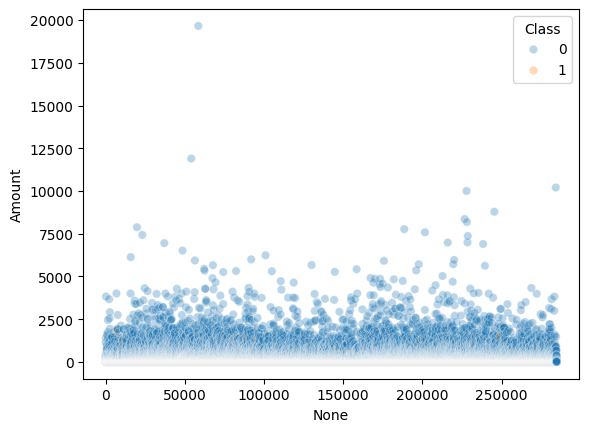

In [16]:
sns.scatterplot(data=df, y= 'Amount', x= df.index, hue='Class', alpha=0.3)

In [17]:
df['Class'].value_counts()

Class
0    199014
1       351
Name: count, dtype: int64

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [19]:
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [65]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
X = df.drop()
y = 

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Class'), df['Class'], test_size=0.2, random_state=42, stratify=df['Class'])

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((159492, 30), (39873, 30), (159492,), (39873,))

In [22]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [25]:
s_kfold = StratifiedKFold(n_splits=30, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, scoring=make_scorer(precision_score), cv = s_kfold)

In [26]:
scores

array([0.06716418, 0.08547009, 0.08196721, 0.07291667, 0.10638298,
       0.07194245, 0.078125  , 0.08849558, 0.09      , 0.08181818,
       0.075     , 0.06557377, 0.07142857, 0.06422018, 0.07079646,
       0.05737705, 0.072     , 0.07826087, 0.0733945 , 0.07017544,
       0.07258065, 0.08035714, 0.07142857, 0.06930693, 0.07758621,
       0.05825243, 0.07692308, 0.07017544, 0.08035714, 0.07438017])

In [29]:
scores.mean()

np.float64(0.07512856374625061)

In [30]:
y_pred = pipe.predict(X_test)

In [32]:
from sklearn.metrics import confusion_matrix

<Axes: >

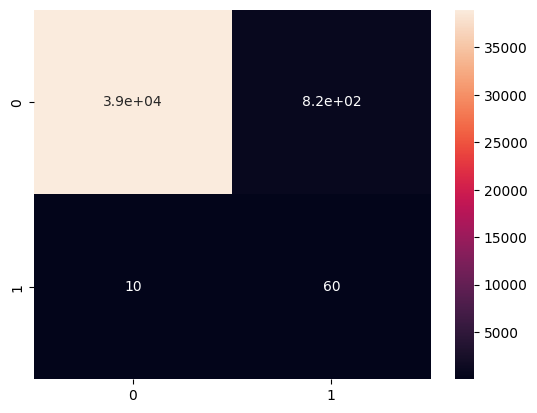

In [33]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [34]:
accuracy_score(y_test, y_pred)

0.9791337496551551

In [36]:
print(classification_report(y_test, y_pred
                     ))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     39803
           1       0.07      0.86      0.13        70

    accuracy                           0.98     39873
   macro avg       0.53      0.92      0.56     39873
weighted avg       1.00      0.98      0.99     39873



In [37]:
test = pd.read_csv('../../Data/test_credit_card.csv')

In [38]:
test_data = test.drop(columns='Class')

In [39]:
y_p = pipe.predict(test_data)

In [40]:
accuracy_score(test['Class'], y_p)

0.978535146649189

In [41]:
df.shape

(199365, 31)

<Axes: >

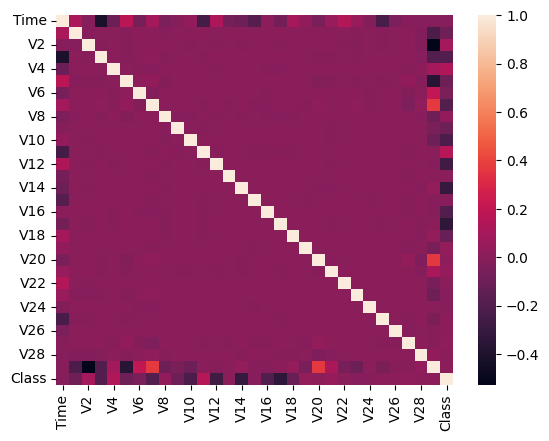

In [42]:
sns.heatmap(df.corr())

In [44]:
df = pd.read_excel('../../Data/E-Commerce Orders.csv.xlsx')

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [46]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [47]:
import seaborn as sns

<Axes: >

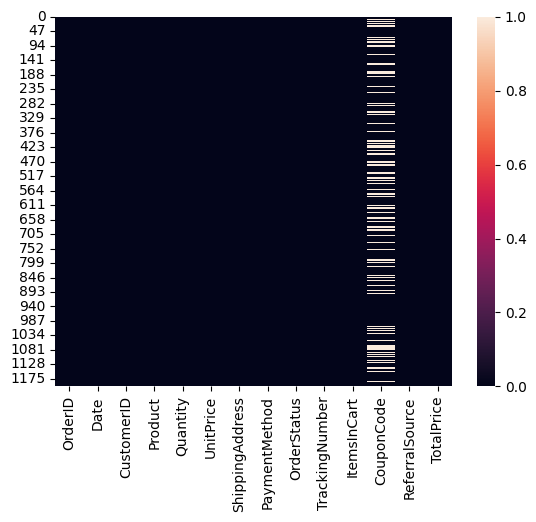

In [48]:
sns.heatmap(df.isnull())